In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

import scipy.stats as stats

np.random.default_rng(42)

Generator(PCG64) at 0x2227169A260

Data import

In [ ]:
data = pd.read_csv()

In [ ]:
data["changes"] = data["Volume"].pct_change()
data.dropna(inplace=True)

Change distribution

In [ ]:
shapiro_test = stats.shapiro(data['changes'])
print("Shapiro-Wilk Test Statistic:", shapiro_test.statistic)
print("Shapiro-Wilk Test p-value:", shapiro_test.pvalue)

Data visualization

In [ ]:
plt.hist(data["changes"])

In [ ]:
plt.plot(data["changes"])

Geometric Brownian Motion simulation

In [ ]:
mu = data["changes"].mean()
sigma = data["changes"].std()
S0 = data["changes"].iloc[-1]  # Initial deposit volume

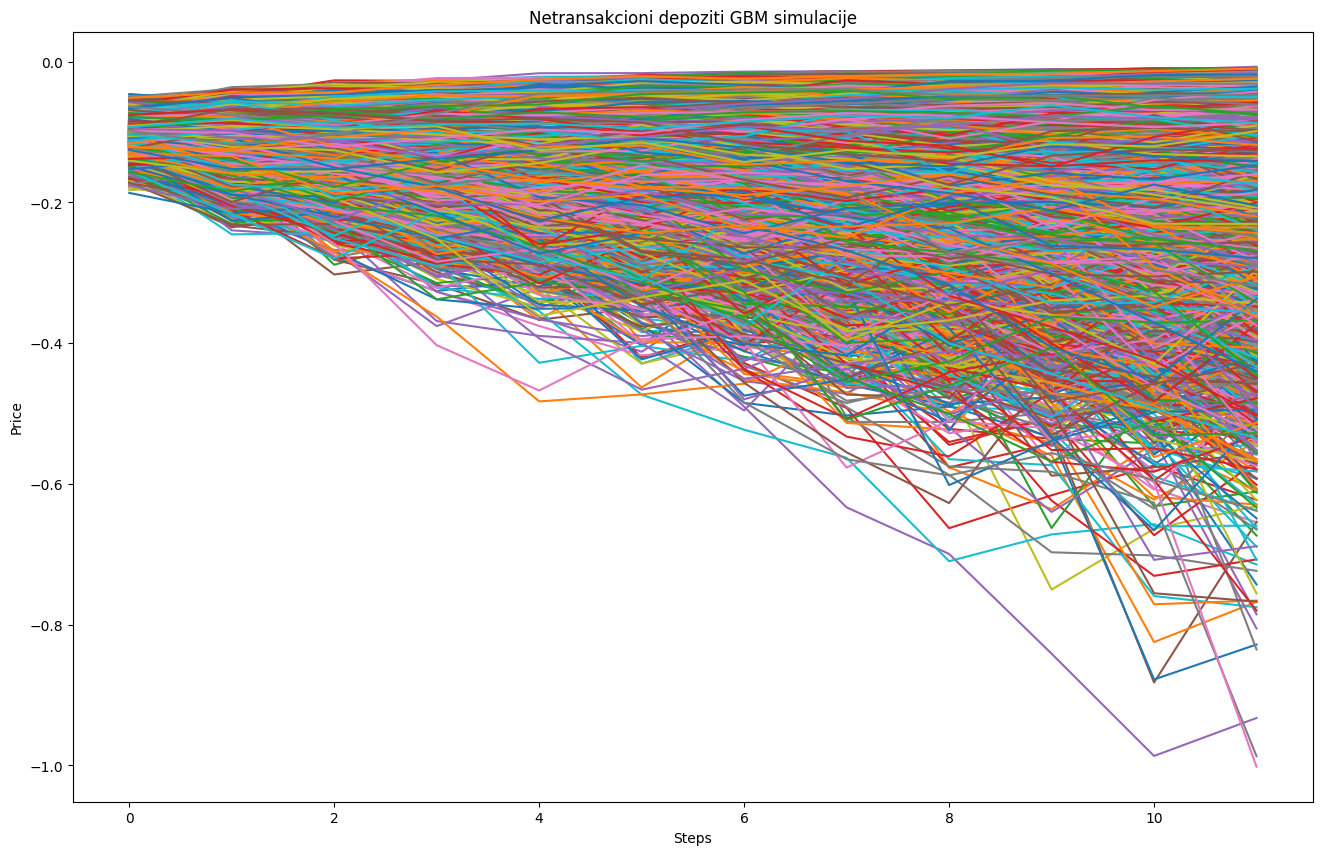

In [ ]:
T = 1 # Time horizon expressed in years
N = 12 # Number of forecasts needed - 12 months

terminal_prices = []
plt.figure(figsize=(16,10))

for i in range(100000):
    dt = 1 / T
    t = np.linspace(0, 1, N)
    W = np.random.standard_normal(size=N)
    W = np.cumsum(W) * np.sqrt(dt)  # Brownian motion
  # X = (mu - 0.5 * sigma**2) * t + sigma * W  # with drift
    X = sigma * W # without drift
    S = S0 * np.exp(X)  # Geometric Brownian motion
    terminal_prices.append(S[-1])
    plt.plot(S, label=f'Simulation {i+1}')

plt.xlabel('Steps')
plt.ylabel('Price')
plt.title('Netransakcioni depoziti GBM simulacije')
plt.show()

terminal_prices = np.array(terminal_prices)

VaR calculation

In [ ]:
changes = terminal_prices / S0 - 1

var_1pct_change = np.percentile(changes, 1)
niv_std_dep = 1 + var_1pct_change

print(f"1% VaR (change): {var_1pct_change:.2%}")
print(f"Utvrdjeni nivo stabilnih depozita je: {niv_std_dep:.2%}")